##установка библиотек

In [1]:
!pip install -U datasets
!pip install msclap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 16.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; pl

In [2]:
!pip uninstall model_finetuning


In [3]:
!pip install --quiet git+https://github.com/artovv/MAI.ARTOV.musicgen-finetuning

  Preparing metadata (setup.py) ... done


##загрузка моделей и весов

In [1]:
from importlib.util import find_spec
import sys
import os

spec = find_spec("model_finetuning")
package_path = os.path.dirname(spec.origin)
if package_path not in sys.path:
    sys.path.append(package_path)

ce_weights_path = os.path.join(package_path, "weights", "fourier_adapter_weights.pt")
crpo_weights_path = os.path.join(package_path, "weights", "fourier_adapter_weights_clap_crpo.pt")

In [2]:
from fourier import FourierFTWrapper, freeze_all_except_fourier, inject_fourierft
import torch

def load_fourier_weights(model, weights_path, n=4500, alpha=208.0, freq_bias="low", bandwidth=0.28):
    #вставка адаптеров
    inject_fourierft(model, n=n, alpha=alpha, freq_bias=freq_bias, bandwidth=bandwidth)

    #заморозка всех параметров кроме delta_W
    freeze_all_except_fourier(model)

    #загрузка сохранённых весов
    delta_weights = torch.load(weights_path, map_location="cpu")
    applied, total = 0, 0

    for name, param in model.named_parameters():
        if "delta_W" in name:
            total += 1
            if name in delta_weights:
                with torch.no_grad():
                    param.copy_(delta_weights[name].to(param.device))
                applied += 1
            else:
                print(f"Не найдено в сохранённых: {name}")
    return model

In [3]:
from transformers import (
    AutoProcessor,
    AutoModelForTextToWaveform,
)

processor = AutoProcessor.from_pretrained("facebook/musicgen-melody")

model1 = AutoModelForTextToWaveform.from_pretrained("facebook/musicgen-melody")
model1.freeze_text_encoder()
model1.freeze_audio_encoder()
model1 = load_fourier_weights(model1, ce_weights_path)

model2 = AutoModelForTextToWaveform.from_pretrained("facebook/musicgen-melody")
model2.freeze_text_encoder()
model2.freeze_audio_encoder()
model2 = load_fourier_weights(model2, crpo_weights_path)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/369 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

Всего вставлено адаптеров: 96
Заморожено параметров: 1,552,138,818, обучаемо (Fourier): 432,000


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Всего вставлено адаптеров: 96
Заморожено параметров: 1,552,138,818, обучаемо (Fourier): 432,000


In [ ]:
model_base = AutoModelForTextToWaveform.from_pretrained("facebook/musicgen-melody")
model_base.freeze_text_encoder()
model_base.freeze_audio_encoder()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

##генерация данных для оценки

In [4]:

from datasets import load_dataset, Audio
from pathlib import Path
import torchaudio

dataset_name = "artovv/musicgen-mystyle"
split = "train"
output_dir = Path("ref_chunks")
output_dir.mkdir(parents=True, exist_ok=True)

dataset = load_dataset(dataset_name, split=split, streaming=False)
dataset = dataset.cast_column("audio", Audio(sampling_rate=32000))

for idx, item in enumerate(dataset):
    audio = item["audio"]["array"]
    path = output_dir / f"chunk_{idx}.wav"
    torchaudio.save(str(path), torch.tensor(audio).unsqueeze(0), 32000)
    if idx % 10 == 0:
        print(f"Сохранено: {path}")

README.md:   0%|          | 0.00/355 [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/132M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/69 [00:00<?, ? examples/s]

Сохранено: ref_chunks/chunk_0.wav
Сохранено: ref_chunks/chunk_10.wav
Сохранено: ref_chunks/chunk_20.wav
Сохранено: ref_chunks/chunk_30.wav
Сохранено: ref_chunks/chunk_40.wav
Сохранено: ref_chunks/chunk_50.wav
Сохранено: ref_chunks/chunk_60.wav


In [5]:
import os
import gc
import torch
import soundfile as sf

def generate_tracks(model, processor, prompt, output_dir, num_tracks=10, guidance_scale=3.0, max_new_tokens=512, samplerate=32000):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device).eval()

    os.makedirs(output_dir, exist_ok=True)

    for i in range(num_tracks):
        print(f"\nГенерация трека {i + 1}/{num_tracks}")

        inputs = processor(text=[prompt], return_tensors="pt").to(device)

        with torch.no_grad():
            audio_values = model.generate(
                **inputs,
                do_sample=True,
                guidance_scale=guidance_scale,
                max_new_tokens=max_new_tokens
            )

        audio = audio_values.cpu().numpy().squeeze()
        path = os.path.join(output_dir, f"gen_{i + 1:02d}.wav")
        sf.write(path, audio, samplerate=samplerate)
        print(f"Сохранено: {path}")

        del audio_values, inputs
        torch.cuda.empty_cache()
        gc.collect()

In [ ]:
generate_tracks(
    model=model_base,
    processor=processor,
    prompt="my_style, Pop, Dance-pop, acousticguitar, groovy",
    output_dir="./generated_base"
)



Генерация трека 1/10
Сохранено: ./generated_base/gen_01.wav

Генерация трека 2/10
Сохранено: ./generated_base/gen_02.wav

Генерация трека 3/10
Сохранено: ./generated_base/gen_03.wav

Генерация трека 4/10
Сохранено: ./generated_base/gen_04.wav

Генерация трека 5/10
Сохранено: ./generated_base/gen_05.wav

Генерация трека 6/10
Сохранено: ./generated_base/gen_06.wav

Генерация трека 7/10
Сохранено: ./generated_base/gen_07.wav

Генерация трека 8/10
Сохранено: ./generated_base/gen_08.wav

Генерация трека 9/10
Сохранено: ./generated_base/gen_09.wav

Генерация трека 10/10
Сохранено: ./generated_base/gen_10.wav

Генерация трека 1/10


OutOfMemoryError: CUDA out of memory. Tried to allocate 18.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 14.12 MiB is free. Process 16163 has 14.72 GiB memory in use. Of the allocated memory 13.31 GiB is allocated by PyTorch, and 1.28 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
generate_tracks(
    model=model1,
    processor=processor,
    prompt="my_style, Pop, Dance-pop, acousticguitar, groovy",
    output_dir="./generated_ce"
)


Генерация трека 1/10
Сохранено: ./generated_ce/gen_01.wav

Генерация трека 2/10
Сохранено: ./generated_ce/gen_02.wav

Генерация трека 3/10
Сохранено: ./generated_ce/gen_03.wav

Генерация трека 4/10
Сохранено: ./generated_ce/gen_04.wav

Генерация трека 5/10
Сохранено: ./generated_ce/gen_05.wav

Генерация трека 6/10
Сохранено: ./generated_ce/gen_06.wav

Генерация трека 7/10
Сохранено: ./generated_ce/gen_07.wav

Генерация трека 8/10
Сохранено: ./generated_ce/gen_08.wav

Генерация трека 9/10
Сохранено: ./generated_ce/gen_09.wav

Генерация трека 10/10
Сохранено: ./generated_ce/gen_10.wav


In [6]:
generate_tracks(
    model=model2,
    processor=processor,
    prompt="my_style, Pop, Dance-pop, acousticguitar, groovy",
    output_dir="./generated_crpo"
)


Генерация трека 1/10
Сохранено: ./generated_crpo/gen_01.wav

Генерация трека 2/10
Сохранено: ./generated_crpo/gen_02.wav

Генерация трека 3/10
Сохранено: ./generated_crpo/gen_03.wav

Генерация трека 4/10
Сохранено: ./generated_crpo/gen_04.wav

Генерация трека 5/10
Сохранено: ./generated_crpo/gen_05.wav

Генерация трека 6/10
Сохранено: ./generated_crpo/gen_06.wav

Генерация трека 7/10
Сохранено: ./generated_crpo/gen_07.wav

Генерация трека 8/10
Сохранено: ./generated_crpo/gen_08.wav

Генерация трека 9/10
Сохранено: ./generated_crpo/gen_09.wav

Генерация трека 10/10
Сохранено: ./generated_crpo/gen_10.wav


In [12]:
import os
import torch
import torchaudio
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from msclap import CLAP
import seaborn as sns
import matplotlib.pyplot as plt

class CLAPEvaluator:
    def __init__(self, device=None, sample_rate=48000):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model = CLAP(version="2023", use_cuda=(self.device == "cuda"))
        self.sample_rate = sample_rate

    def load_audio(self, path, max_sec=5):
        waveform, sr = torchaudio.load(path)
        if sr != self.sample_rate:
            waveform = torchaudio.transforms.Resample(sr, self.sample_rate)(waveform)
        max_len = self.sample_rate * max_sec
        if waveform.shape[1] > max_len:
            waveform = waveform[:, :max_len]
        return waveform[0].unsqueeze(0)

    def get_audio_embedding(self, path):
        emb = self.model.get_audio_embeddings([str(path)])[0]
        return emb.cpu().numpy()

    def get_text_embedding(self, prompt):
        return self.model.get_text_embeddings([prompt])[0].cpu().numpy()

    def evaluate_similarity(self, generated_dir, reference_dir, save_csv=True):
        gen_paths = sorted(Path(generated_dir).glob("*.wav"))
        ref_paths = sorted(Path(reference_dir).glob("*.wav"))
        results = []

        for gen_path in tqdm(gen_paths, desc="Similarity Evaluation"):
            try:
                gen_emb = self.get_audio_embedding(gen_path)
                similarities = []

                for ref_path in ref_paths:
                    try:
                        ref_emb = self.get_audio_embedding(ref_path)
                        sim = cosine_similarity([gen_emb], [ref_emb])[0][0]
                        similarities.append(sim)
                        results.append({
                            "generated": gen_path.name,
                            "reference": ref_path.name,
                            "similarity": sim
                        })
                    except Exception as e:
                        print(f"Ошибка с reference {ref_path.name}: {e}")

                if similarities:
                    avg_sim = sum(similarities) / len(similarities)
                    print(f"{gen_path.name}: средняя similarity = {avg_sim:.4f}")
            except Exception as e:
                print(f"Ошибка с generated {gen_path.name}: {e}")

        df = pd.DataFrame(results)
        if len(df) == 0:
            print("Ошибка: не удалось извлечь ни одного сходства.")
            return df

        if save_csv:
            df.to_csv("clap_full_pairwise.csv", index=False)
            mean_df = df.groupby("generated")["similarity"].mean().reset_index()
            mean_df.to_csv("clap_mean_similarity.csv", index=False)
            print("Сохранено: clap_full_pairwise.csv и clap_mean_similarity.csv")

        return df

    def evaluate_diversity(self, generated_dir, save_matrix=True):
        gen_paths = sorted(Path(generated_dir).glob("*.wav"))
        embeddings = []

        for path in tqdm(gen_paths, desc="Embedding"):
            try:
                emb = self.get_audio_embedding(path)
                embeddings.append(emb)
            except Exception as e:
                print(f"{path.name}: {e}")

        if not embeddings:
            raise ValueError("Нет валидных эмбеддингов для оценки Diversity.")

        embeddings = np.stack(embeddings)
        sim_matrix = cosine_similarity(embeddings)

        df = pd.DataFrame(sim_matrix, index=[p.name for p in gen_paths], columns=[p.name for p in gen_paths])

        if save_matrix:
            df.to_csv("clap_diversity_matrix.csv")

        return df

In [8]:
def plot_similarity_metrics(similarity_df):
    mean_df = similarity_df.groupby("generated")["similarity"].mean().reset_index()
    mean_df.to_csv("clap_mean_similarity.csv", index=False)
    print("Сохранено: clap_mean_similarity.csv")

    plt.figure(figsize=(8, 4))
    sns.histplot(mean_df["similarity"], bins=10, kde=True, color="cornflowerblue")
    plt.title("CLAP Mean Similarity per Generated Track")
    plt.xlabel("Average Cosine Similarity")
    plt.ylabel("Number of Generated Tracks")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    mean_val = mean_df["similarity"].mean()
    print(f"Среднее сходство по всем сгенерированным трекам: {mean_val:.4f}")
    return mean_val

In [9]:
def plot_diversity_metrics(df: pd.DataFrame):
    sim_matrix = df.values
    mask = ~np.eye(len(sim_matrix), dtype=bool)
    avg_sim = sim_matrix[mask].mean()
    diversity_score = 1.0 - avg_sim

    plt.figure(figsize=(8, 4))
    sns.histplot(sim_matrix[mask], bins=15, kde=True, color="orchid")
    plt.title("CLAP Similarity Between Generated Tracks")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Count")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"Средняя косинусная схожесть между сгенерированными: {avg_sim:.4f}")
    print(f"CLAP Diversity Score: {diversity_score:.4f}")

#оценка моделей

##base model

Similarity Evaluation: 100%|██████████| 10/10 [00:40<00:00,  4.03s/it]gen_10.wav: средняя similarity = 0.4622
Сохранено: clap_full_pairwise.csv и clap_mean_similarity.csv
Сохранено: clap_mean_similarity.csv


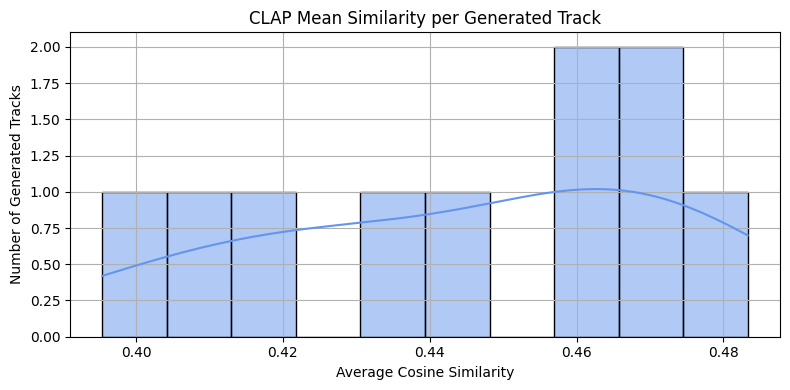

Среднее сходство по всем сгенерированным трекам: 0.4451


In [ ]:
evaluator = CLAPEvaluator()

df_sim = evaluator.evaluate_similarity("generated_base", "ref_chunks")
plot_similarity_metrics(df_sim)


##модель 1(cross entropy)

Similarity Evaluation: 100%|██████████| 10/10 [00:39<00:00,  3.98s/it]gen_10.wav: средняя similarity = 0.5932
Сохранено: clap_full_pairwise.csv и clap_mean_similarity.csv
Сохранено: clap_mean_similarity.csv


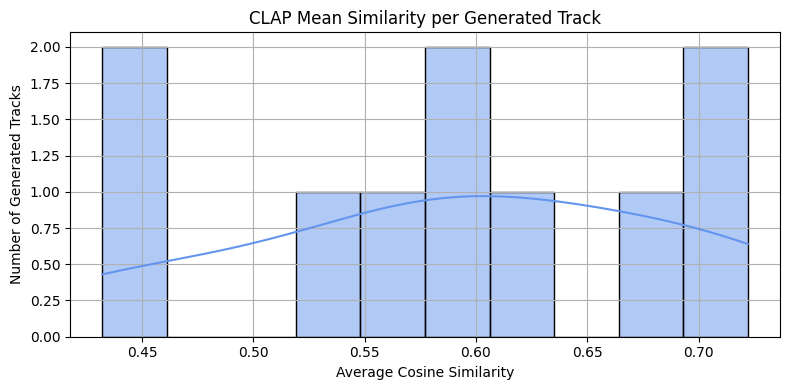

Среднее сходство по всем сгенерированным трекам: 0.5931


In [ ]:
evaluator = CLAPEvaluator()

df_sim = evaluator.evaluate_similarity("generated_ce", "ref_chunks")
plot_similarity_metrics(df_sim)


Embedding: 100%|██████████| 10/10 [00:00<00:00, 10.33it/s]


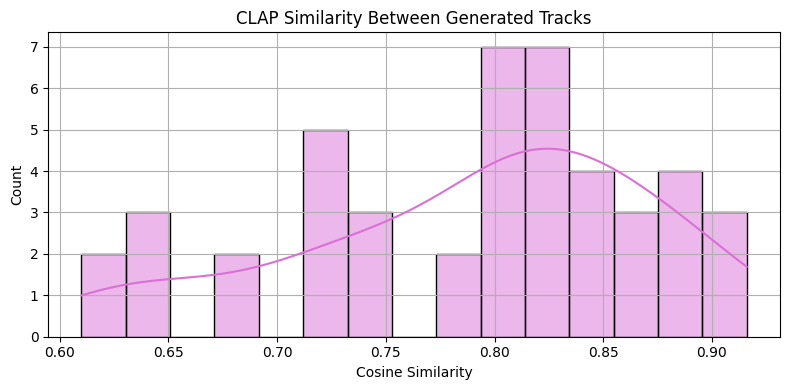

Средняя косинусная схожесть между сгенерированными: 0.7895
CLAP Diversity Score: 0.2105


In [44]:
diversity_df = evaluator.evaluate_diversity("generated_ce")
plot_diversity_metrics(diversity_df)

##модель 2(crpo)

Similarity Evaluation: 100%|██████████| 10/10 [00:39<00:00,  3.91s/it]gen_10.wav: средняя similarity = 0.6791
Сохранено: clap_full_pairwise.csv и clap_mean_similarity.csv
Сохранено: clap_mean_similarity.csv


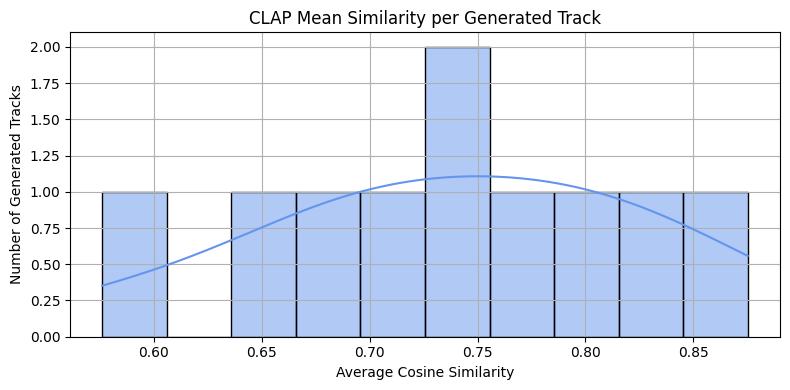

Среднее сходство по всем сгенерированным трекам: 0.7396


In [ ]:
evaluator = CLAPEvaluator()

df_sim = evaluator.evaluate_similarity("generated_crpo", "ref_chunks")
plot_similarity_metrics(df_sim)

Embedding: 100%|██████████| 10/10 [00:00<00:00, 21.92it/s]


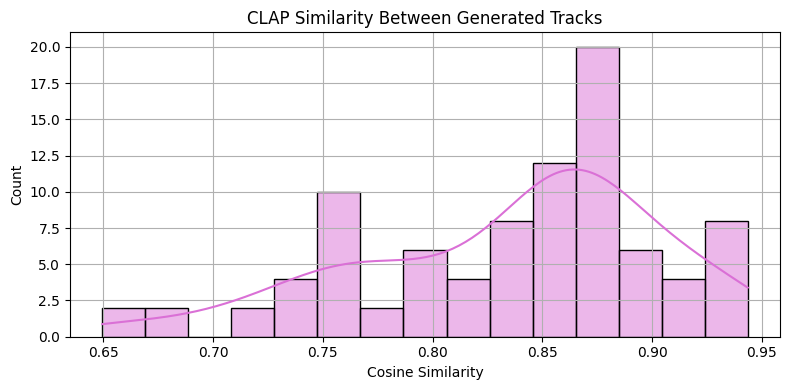

Средняя косинусная схожесть между сгенерированными: 0.8346
CLAP Diversity Score: 0.1654


In [21]:
evaluator = CLAPEvaluator()
diversity_df = evaluator.evaluate_diversity("generated_crpo")
plot_diversity_metrics(diversity_df)
